In [ ]:
import os
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ----------------------------
# CONFIG
# ----------------------------
data_file = "aggregated_data_2022_2023.csv"
out_dir = "disagg_results/nn_region_supervised"
os.makedirs(out_dir, exist_ok=True)

region_grid_side = 10          # 10x10 regions
sub_grid_side = 100            # 100x100 subregions total
sub_per_region_side = sub_grid_side // region_grid_side  # 10
subcells_per_region = sub_per_region_side * sub_per_region_side  # 100

n_epochs = 500
lr = 3e-4
seed = 42
device = "cuda" if torch.cuda.is_available() else "cpu"

np.random.seed(seed)
torch.manual_seed(seed)
print(f"Device: {device}")

# ----------------------------
# LOAD + CLEAN DATA
# ----------------------------
df = pd.read_csv(data_file)
df = df.replace([np.inf, -np.inf], np.nan)

# Required columns
required = ["row_id", "column_id", "week_id", "temperature", "urbanization", "gun_incidents"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns in CSV: {missing}")

df["gun_incidents"] = df["gun_incidents"].fillna(0)
df["temperature"] = df["temperature"].fillna(df["temperature"].median())
df["urbanization"] = df["urbanization"].fillna(df["urbanization"].median())
df["row_id"] = df["row_id"].astype(int)
df["column_id"] = df["column_id"].astype(int)

weeks = sorted(df["week_id"].unique())
T = len(weeks)
print(f"Total timesteps (weeks): {T}")

# ----------------------------
# REGION INDEXING
# ----------------------------
def cell_to_region_index(row, col):
    ri = row // sub_per_region_side
    rj = col // sub_per_region_side
    return ri * region_grid_side + rj

df["region_id"] = [cell_to_region_index(r, c) for r, c in zip(df.row_id, df.column_id)]

# Quick sanity: expected 100 regions
n_regions = df["region_id"].nunique()
print("Unique regions:", n_regions)
if n_regions != region_grid_side * region_grid_side:
    print(f"WARNING: expected {region_grid_side*region_grid_side} regions, found {n_regions}.")

# ----------------------------
# BUILD URBANIZATION MAP (fixed over time)
# ----------------------------
# Assumes urbanization is time-invariant or you want the mean over time for each cell.
urbanization_map = df.groupby(["row_id", "column_id"])["urbanization"].mean().unstack().values
if urbanization_map.shape != (sub_grid_side, sub_grid_side):
    raise ValueError(f"urbanization_map shape {urbanization_map.shape} != ({sub_grid_side},{sub_grid_side}). "
                     "Check row_id/column_id indexing range.")

context_sub = torch.tensor(urbanization_map, dtype=torch.float32, device=device)

# ----------------------------
# BUILD REGION TEMPERATURE + REGION OUTCOME PER WEEK
# ----------------------------
region_temp_T, region_outcome_T = [], []

# Get the median temperature from the entire dataframe to use for filling missing region temperatures
median_temp_for_fill = df["temperature"].median()

# Create a full index of all possible region_ids (0 to n_regions-1)
full_region_index = pd.RangeIndex(start=0, stop=n_regions)

for wk in weeks:
    subdf = df[df.week_id == wk]

    # region-level temperature mean within (week, region)
    # Reindex to ensure all regions are present, fill missing with the overall median temperature
    temp_series = subdf.groupby("region_id")["temperature"].mean().reindex(full_region_index)
    temp_mean = temp_series.fillna(median_temp_for_fill).values

    # region-level gun incidents within (week, region)
    # Reindex to ensure all regions are present, fill missing with 0 (as incidents are counts)
    # If gun_incidents is truly region-level and repeated on each of the 100 subcells:
    #   use .mean() or .first() (already using mean)
    # outcome_series = subdf.groupby("region_id")["gun_incidents"].mean().reindex(full_region_index)
    outcome_region = outcome_series.fillna(0).values # Fill missing region outcomes with 0

    # If gun_incidents is actually per-subcell and you need region total, use this instead:
    outcome_region = subdf.groupby("region_id")["gun_incidents"].sum().reindex(full_region_index).fillna(0).values

    region_temp_T.append(temp_mean)
    region_outcome_T.append(outcome_region)

region_temp_T = np.stack(region_temp_T, axis=0)         # (T, 100)
region_outcome_T = np.stack(region_outcome_T, axis=0)   # (T, 100)

# Normalize temperature across all weeks/regions
mean_temp = float(np.nanmean(region_temp_T))
std_temp = float(np.nanstd(region_temp_T))
region_temp_T_norm = (region_temp_T - mean_temp) / (std_temp + 1e-8)

temp_reg_T_t = torch.tensor(region_temp_T_norm, dtype=torch.float32, device=device)      # (T,100)
outcome_reg_T_t = torch.tensor(region_outcome_T, dtype=torch.float32, device=device)     # (T,100)

print("temp_reg_T_t:", tuple(temp_reg_T_t.shape))
print("outcome_reg_T_t:", tuple(outcome_reg_T_t.shape))

# ----------------------------
# LOSS
# ----------------------------
def poisson_sum_nll(pred_sum, true_count, eps=1e-8):
    # pred_sum and true_count: (100,)
    return torch.mean(pred_sum - true_count * torch.log(pred_sum + eps))

# ----------------------------
# MODEL (NN f(temp, urban) with region-sum aggregation)
# ----------------------------
class DisaggNN(nn.Module):
    def __init__(self, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 1),
        )
        # critical: avoid dead gradients (works much better than ReLU at output)
        self.softplus = nn.Softplus(beta=1.0)

    def forward(self, temp_reg_t, context_sub):
        """
        temp_reg_t: (100,) normalized region temperatures for a given week
        context_sub: (100,100) urbanization map
        Returns:
          rate_sub: (100,100) subcell rates
          pred_reg_sum: (100,) region sums
        """
        # (100,) -> (10,10)
        temp_reg_mat = temp_reg_t.view(region_grid_side, region_grid_side)

        # expand to subgrid (100,100) by repeating each region value into its 10x10 block
        temp_grid = temp_reg_mat.repeat_interleave(sub_per_region_side, dim=0)\
                                .repeat_interleave(sub_per_region_side, dim=1)  # (100,100)

        # features per subcell
        t = temp_grid.reshape(-1, 1)         # (10000,1)
        u = context_sub.reshape(-1, 1)       # (10000,1)
        x = torch.cat([t, u], dim=1)         # (10000,2)

        # predict subcell rate
        rate = self.softplus(self.net(x)) + 1e-6   # (10000,1)
        rate_sub = rate.view(sub_grid_side, sub_grid_side)  # (100,100)

        # aggregate to regions: reshape into (region_i, within_i, region_j, within_j)
        # rows: 100 = 10 regions * 10 subrows; cols similarly
        blocks = rate_sub.view(region_grid_side, sub_per_region_side,
                               region_grid_side, sub_per_region_side)  # (10,10,10,10)

        # sum within each region block (over the 10x10 inside-block dims)
        pred_reg = blocks.sum(dim=(1, 3))  # (10,10)
        pred_reg_sum = pred_reg.reshape(-1)  # (100,)

        return rate_sub, pred_reg_sum

# ----------------------------
# TRAIN
# ----------------------------
model = DisaggNN(hidden=64).to(device)
opt = torch.optim.Adam(model.parameters(), lr=lr)

loss_hist = []

for epoch in range(n_epochs):
    total_loss = 0.0

    for t in range(T):
        temp_reg_t = temp_reg_T_t[t]          # (100,)
        outcome_reg_t = outcome_reg_T_t[t]    # (100,)

        _, pred_reg_sum_t = model(temp_reg_t, context_sub)
        loss = poisson_sum_nll(pred_reg_sum_t, outcome_reg_t)

        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

        total_loss += loss.item()

    avg_loss = total_loss / T
    loss_hist.append(avg_loss)

    if (epoch + 1) % 50 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{n_epochs}: Poisson NLL = {avg_loss:.6f}")

# Save model + loss
torch.save(model.state_dict(), os.path.join(out_dir, "nn_weights.pt"))
pd.DataFrame({"loss": loss_hist}).to_csv(os.path.join(out_dir, "training_loss.csv"), index=False)

plt.figure(figsize=(6,4))
plt.plot(loss_hist)
plt.xlabel("Epoch")
plt.ylabel("Poisson NLL")
plt.title("Training Loss (NN region-supervised)")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "training_loss_curve.png"), dpi=200)
plt.close()

print("Saved weights + training curve to:", out_dir)

# ----------------------------
# PREDICT & SAVE SUBREGIONAL MAPS PER WEEK
# ----------------------------
model.eval()
pred_all = []

with torch.no_grad():
    for t in range(T):
        rate_sub_t, _ = model(temp_reg_T_t[t], context_sub)  # (100,100)
        pred_all.append(rate_sub_t.cpu().numpy())
        np.save(os.path.join(out_dir, f"predicted_subregion_intensity_week{weeks[t]}.npy"), pred_all[-1])

print("Saved predicted subregion intensity maps for all weeks.")

# ----------------------------
# TRUE VS PREDICTED MAPS (SAMPLE WEEKS)
# ----------------------------
sample_weeks_idx = np.linspace(0, T-1, 5, dtype=int)

for t in sample_weeks_idx:
    wk = weeks[t]

    # Build a "true map" from df for visualization.
    # If gun_incidents is region-level, this will show the same value across each region's 10x10 subcells.
    true_map = np.zeros((sub_grid_side, sub_grid_side), dtype=np.float32)
    subdf = df[df.week_id == wk]
    for _, row in subdf.iterrows():
        true_map[int(row.row_id), int(row.column_id)] = float(row.gun_incidents)

    pred_map = pred_all[t]
    vmax = float(max(true_map.max(), pred_map.max()))

    fig, axes = plt.subplots(1, 2, figsize=(12,6))
    im0 = axes[0].imshow(true_map, origin="lower", cmap="viridis", vmin=0, vmax=vmax)
    axes[0].set_title(f"True Map (week={wk})")
    im1 = axes[1].imshow(pred_map, origin="lower", cmap="viridis", vmin=0, vmax=vmax)
    axes[1].set_title(f"Predicted Subregion Intensity (week={wk})")
    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])
    cbar = fig.colorbar(im1, ax=axes.ravel().tolist(), fraction=0.046, pad=0.04)
    cbar.set_label("Gun incidents (count / intensity)")
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"true_vs_predicted_week{wk}.png"), dpi=300, bbox_inches="tight")
    plt.close()

print("Saved true vs predicted comparison images for sample weeks.")

# ----------------------------
# LEARNED FUNCTION HEATMAP f(temp, urban)
# ----------------------------
# We evaluate the learned NN on a grid of (temp_norm, urbanization) pairs.
t_vals = np.linspace(region_temp_T_norm.min(), region_temp_T_norm.max(), 200).astype(np.float32)
u_vals = np.linspace(float(context_sub.min().cpu()), float(context_sub.max().cpu()), 200).astype(np.float32)
Tg, Ug = np.meshgrid(t_vals, u_vals)

t_t = torch.tensor(Tg, dtype=torch.float32, device=device).reshape(-1, 1)
u_t = torch.tensor(Ug, dtype=torch.float32, device=device).reshape(-1, 1)
x = torch.cat([t_t, u_t], dim=1)

with torch.no_grad():
    lam = model.softplus(model.net(x)) + 1e-6
    lam_img = lam.reshape(200, 200).cpu().numpy()

plt.figure(figsize=(7,6))
plt.imshow(
    lam_img,
    origin="lower",
    extent=[t_vals.min(), t_vals.max(), u_vals.min(), u_vals.max()],
    aspect="auto",
    cmap="plasma"
)
plt.colorbar(label="Predicted subcell rate λ̂(t,u)")
plt.xlabel("Normalized Temperature (region mean)")
plt.ylabel("Urbanization (subregion)")
plt.title("Learned function f(temp, urban) (NN)")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "learned_function_heatmap.png"), dpi=300)
plt.close()

print("✅ Done! Outputs saved in:", out_dir)


Device: cpu
Total timesteps (weeks): 104
Unique regions: 100
temp_reg_T_t: (104, 100)
outcome_reg_T_t: (104, 100)
Epoch 1/500: Poisson NLL = 45.209716
Epoch 50/500: Poisson NLL = 0.185342
Epoch 100/500: Poisson NLL = 0.176617
Epoch 150/500: Poisson NLL = 0.172731
Epoch 200/500: Poisson NLL = 0.170303
Epoch 250/500: Poisson NLL = 0.168792
Epoch 300/500: Poisson NLL = 0.167695
Epoch 350/500: Poisson NLL = 0.166648
Epoch 400/500: Poisson NLL = 0.165789
Epoch 450/500: Poisson NLL = 0.165154
Epoch 500/500: Poisson NLL = 0.164500
Saved weights + training curve to: disagg_results/nn_region_supervised
Saved predicted subregion intensity maps for all weeks.


/tmp/ipython-input-1995367805.py:269: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved true vs predicted comparison images for sample weeks.
✅ Done! Outputs saved in: disagg_results/nn_region_supervised


In [ ]:
# ============================================================
# FULL RUNNABLE SCRIPT (PyTorch) + EARLY STOPPING + RAW-TEMP HEATMAP AXIS
# ============================================================
# Setup:
# - Space: 10x10 regions
# - Each region: 10x10 subregions => 100x100 sub-grid
# - week_id is the time index (each week is one datapoint)
# - Inputs:
#     * temperature at REGION level (per week): mean of cells in region
#     * urbanization at SUBREGION level: fixed map (mean over time)
# - Target:
#     * gun_incidents at REGION level (per week)
# - Model:
#     f(temp_region_mean, urban_cell) -> subcell rate
#     region prediction = sum over 10x10 cells in region
# - No aggregation over time. Validation = held-out weeks.
# ============================================================

import os
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

# ----------------------------
# CONFIG
# ----------------------------
data_file = "aggregated_data_2022_2023.csv"
out_dir = "disagg_results/nn_region_supervised"
os.makedirs(out_dir, exist_ok=True)

region_grid_side = 10          # 10x10 regions
sub_grid_side = 100            # 100x100 subregions total
sub_per_region_side = sub_grid_side // region_grid_side  # 10
subcells_per_region = sub_per_region_side * sub_per_region_side  # 100

n_epochs = 2000
lr = 3e-4
seed = 42
device = "cuda" if torch.cuda.is_available() else "cpu"

# Early stopping
patience = 25
min_delta = 1e-5               # require at least this much improvement
ckpt_path = os.path.join(out_dir, "best_model.pt")

# Validation split (by weeks)
val_frac = 0.2

np.random.seed(seed)
torch.manual_seed(seed)
print(f"Device: {device}")

# ----------------------------
# LOAD + CLEAN DATA
# ----------------------------
df = pd.read_csv(data_file)
df = df.replace([np.inf, -np.inf], np.nan)

required = ["row_id", "column_id", "week_id", "temperature", "urbanization", "gun_incidents"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns in CSV: {missing}")

df["gun_incidents"] = df["gun_incidents"].fillna(0)
df["temperature"] = df["temperature"].fillna(df["temperature"].median())
df["urbanization"] = df["urbanization"].fillna(df["urbanization"].median())
df["row_id"] = df["row_id"].astype(int)
df["column_id"] = df["column_id"].astype(int)

weeks = sorted(df["week_id"].unique())
T = len(weeks)
print(f"Total timesteps (weeks): {T}")

# ----------------------------
# REGION INDEXING
# ----------------------------
def cell_to_region_index(row, col):
    ri = row // sub_per_region_side
    rj = col // sub_per_region_side
    return ri * region_grid_side + rj

df["region_id"] = [cell_to_region_index(r, c) for r, c in zip(df.row_id, df.column_id)]

n_regions = df["region_id"].nunique()
print("Unique regions:", n_regions)
if n_regions != region_grid_side * region_grid_side:
    print(f"WARNING: expected {region_grid_side*region_grid_side} regions, found {n_regions}.")

# ----------------------------
# URBANIZATION MAP (fixed)
# ----------------------------
urbanization_map = df.groupby(["row_id", "column_id"])["urbanization"].mean().unstack().values
if urbanization_map.shape != (sub_grid_side, sub_grid_side):
    raise ValueError(
        f"urbanization_map shape {urbanization_map.shape} != ({sub_grid_side},{sub_grid_side}). "
        "Check row_id/column_id indexing."
    )
context_sub = torch.tensor(urbanization_map, dtype=torch.float32, device=device)

# ----------------------------
# BUILD REGION TEMP + REGION OUTCOME per WEEK
# ----------------------------
region_temp_T_raw, region_outcome_T = [], []

# Get the median temperature from the entire dataframe to use for filling missing region temperatures
median_temp_for_fill = df["temperature"].median()

# Create a full index of all possible region_ids (0 to n_regions-1)
full_region_index = pd.RangeIndex(start=0, stop=n_regions)

for wk in weeks:
    subdf = df[df.week_id == wk]

    # region-level temperature mean within (week, region)
    # Reindex to ensure all regions are present, fill missing with the overall median temperature
    temp_series = subdf.groupby("region_id")["temperature"].mean().reindex(full_region_index)
    temp_mean = temp_series.fillna(median_temp_for_fill).values

    # REGION-LEVEL target per (week,region):
    # If gun_incidents is region-level repeated on each cell: use mean or first.
    # Reindex to ensure all regions are present, fill missing with 0 (as incidents are counts)
    outcome_series = subdf.groupby("region_id")["gun_incidents"].sum().reindex(full_region_index)
    outcome_region = outcome_series.fillna(0).values

    # If gun_incidents is per-cell and you need region totals, switch to:
    # outcome_region = subdf.groupby("region_id")["gun_incidents"].sum().sort_index().values

    region_temp_T_raw.append(temp_mean)
    region_outcome_T.append(outcome_region)

region_temp_T_raw = np.stack(region_temp_T_raw, axis=0)       # (T,100) raw temp
region_outcome_T = np.stack(region_outcome_T, axis=0)         # (T,100)

# Normalize temperature for training
mean_temp = float(np.nanmean(region_temp_T_raw))
std_temp = float(np.nanstd(region_temp_T_raw))
region_temp_T_norm = (region_temp_T_raw - mean_temp) / (std_temp + 1e-8)

temp_reg_T_t = torch.tensor(region_temp_T_norm, dtype=torch.float32, device=device)     # (T,100)
outcome_reg_T_t = torch.tensor(region_outcome_T, dtype=torch.float32, device=device)    # (T,100)

print("temp_reg_T_t:", tuple(temp_reg_T_t.shape))
print("outcome_reg_T_t:", tuple(outcome_reg_T_t.shape))

# ----------------------------
# Train/Val split by WEEKS (no time aggregation, just holdout)
# ----------------------------
week_indices = np.arange(T)
train_w_idx, val_w_idx = train_test_split(week_indices, test_size=val_frac, random_state=seed)
train_w_idx = np.sort(train_w_idx)
val_w_idx = np.sort(val_w_idx)

print(f"Train weeks: {len(train_w_idx)} | Val weeks: {len(val_w_idx)}")

# ----------------------------
# LOSS
# ----------------------------
def poisson_sum_nll(pred_sum, true_count, eps=1e-8):
    return torch.mean(pred_sum - true_count * torch.log(pred_sum + eps))

# ----------------------------
# MODEL
# ----------------------------
class DisaggNN(nn.Module):
    def __init__(self, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 1),
        )
        self.softplus = nn.Softplus(beta=1.0)

    def forward(self, temp_reg_t, context_sub):
        # temp_reg_t: (100,) normalized region temps for a given week
        temp_reg_mat = temp_reg_t.view(region_grid_side, region_grid_side)

        temp_grid = temp_reg_mat.repeat_interleave(sub_per_region_side, dim=0)\
                                .repeat_interleave(sub_per_region_side, dim=1)  # (100,100)

        t = temp_grid.reshape(-1, 1)        # (10000,1)
        u = context_sub.reshape(-1, 1)      # (10000,1)
        x = torch.cat([t, u], dim=1)        # (10000,2)

        rate = self.softplus(self.net(x)) + 1e-6
        rate_sub = rate.view(sub_grid_side, sub_grid_side)

        blocks = rate_sub.view(region_grid_side, sub_per_region_side,
                               region_grid_side, sub_per_region_side)
        pred_reg = blocks.sum(dim=(1, 3))         # (10,10)
        pred_reg_sum = pred_reg.reshape(-1)       # (100,)

        return rate_sub, pred_reg_sum

# ----------------------------
# TRAIN + EARLY STOPPING
# ----------------------------
model = DisaggNN(hidden=64).to(device)
opt = torch.optim.Adam(model.parameters(), lr=lr)

train_loss_hist = []
val_loss_hist = []

best_val = float("inf")
best_state = None
bad_epochs = 0

for epoch in range(n_epochs):
    # ---- train ----
    model.train()
    total_train = 0.0
    for t in train_w_idx:
        temp_reg_t = temp_reg_T_t[t]
        outcome_reg_t = outcome_reg_T_t[t]

        _, pred_reg_sum_t = model(temp_reg_t, context_sub)
        loss = poisson_sum_nll(pred_reg_sum_t, outcome_reg_t)

        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

        total_train += loss.item()
    avg_train = total_train / len(train_w_idx)
    train_loss_hist.append(avg_train)

    # ---- val ----
    model.eval()
    total_val = 0.0
    with torch.no_grad():
        for t in val_w_idx:
            temp_reg_t = temp_reg_T_t[t]
            outcome_reg_t = outcome_reg_T_t[t]
            _, pred_reg_sum_t = model(temp_reg_t, context_sub)
            loss = poisson_sum_nll(pred_reg_sum_t, outcome_reg_t)
            total_val += loss.item()
    avg_val = total_val / len(val_w_idx)
    val_loss_hist.append(avg_val)

    if (epoch + 1) % 25 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{n_epochs} | train={avg_train:.6f} | val={avg_val:.6f}")

    # ---- early stopping ----
    if avg_val < best_val - min_delta:
        best_val = avg_val
        best_state = copy.deepcopy(model.state_dict())
        torch.save(best_state, ckpt_path)
        bad_epochs = 0
    else:
        bad_epochs += 1
        if bad_epochs >= patience:
            print(f"Early stopping at epoch {epoch+1}. Best val={best_val:.6f}")
            break

if best_state is not None:
    model.load_state_dict(best_state)

# Save loss curves
pd.DataFrame({"train_loss": train_loss_hist, "val_loss": val_loss_hist}).to_csv(
    os.path.join(out_dir, "train_val_loss.csv"), index=False
)

plt.figure(figsize=(6,4))
plt.plot(train_loss_hist, label="train")
plt.plot(val_loss_hist, label="val")
plt.xlabel("Epoch")
plt.ylabel("Poisson NLL")
plt.title("Training / Validation Loss (NN)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "train_val_loss_curve.png"), dpi=200)
plt.close()

print("Saved best model to:", ckpt_path)
print("Saved loss curves to:", out_dir)

# ----------------------------
# PREDICT & SAVE SUBREGION MAPS PER WEEK (optional)
# ----------------------------
model.eval()
pred_all = []
with torch.no_grad():
    for t in range(T):
        rate_sub_t, _ = model(temp_reg_T_t[t], context_sub)
        pred_all.append(rate_sub_t.cpu().numpy())
        np.save(os.path.join(out_dir, f"predicted_subregion_intensity_week{weeks[t]}.npy"), pred_all[-1])
print("Saved predicted subregion intensity maps for all weeks.")

# ----------------------------
# LEARNED FUNCTION HEATMAP f(temp, urban) ON RAW TEMP AXIS
# ----------------------------
# We plot temperature on the RAW scale, but convert to normalized before feeding the model.
t_raw_min = float(np.min(region_temp_T_raw))
t_raw_max = float(np.max(region_temp_T_raw))
u_min = float(context_sub.min().cpu())
u_max = float(context_sub.max().cpu())

t_vals_raw = np.linspace(t_raw_min, t_raw_max, 250).astype(np.float32)
u_vals = np.linspace(u_min, u_max, 250).astype(np.float32)
Tg_raw, Ug = np.meshgrid(t_vals_raw, u_vals)

# normalize temperature for model input
Tg_norm = (Tg_raw - mean_temp) / (std_temp + 1e-8)

t_t = torch.tensor(Tg_norm, dtype=torch.float32, device=device).reshape(-1, 1)
u_t = torch.tensor(Ug, dtype=torch.float32, device=device).reshape(-1, 1)
x = torch.cat([t_t, u_t], dim=1)

with torch.no_grad():
    lam = model.softplus(model.net(x)) + 1e-6
    lam_img = lam.reshape(len(u_vals), len(t_vals_raw)).cpu().numpy()

plt.figure(figsize=(7,6))
plt.imshow(
    lam_img,
    origin="lower",
    extent=[t_vals_raw.min(), t_vals_raw.max(), u_vals.min(), u_vals.max()],
    aspect="auto",
    cmap="plasma"
)
plt.colorbar(label="Predicted subcell rate λ̂(temp, urban)")
plt.xlabel("Temperature (RAW, region mean)")
plt.ylabel("Urbanization (subregion)")
plt.title("Learned function f(temp, urban) (NN) — raw temperature axis")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "learned_function_heatmap_raw_temp_axis.png"), dpi=300)
plt.close()

print("✅ Done! Outputs saved in:", out_dir)


Device: cpu
Total timesteps (weeks): 104
Unique regions: 100
temp_reg_T_t: (104, 100)
outcome_reg_T_t: (104, 100)
Train weeks: 83 | Val weeks: 21
Epoch 1/2000 | train=49.706195 | val=31.492209
Epoch 25/2000 | train=0.205051 | val=0.228736
Epoch 50/2000 | train=0.185849 | val=0.209820
Epoch 75/2000 | train=0.179325 | val=0.203900
Epoch 100/2000 | train=0.175881 | val=0.201661
Epoch 125/2000 | train=0.173558 | val=0.200148
Epoch 150/2000 | train=0.171837 | val=0.199219
Epoch 175/2000 | train=0.170532 | val=0.198369
Epoch 200/2000 | train=0.169555 | val=0.197705
Epoch 225/2000 | train=0.168762 | val=0.197325
Epoch 250/2000 | train=0.168099 | val=0.196976
Epoch 275/2000 | train=0.167496 | val=0.196471
Epoch 300/2000 | train=0.166957 | val=0.196110
Epoch 325/2000 | train=0.166487 | val=0.195843
Epoch 350/2000 | train=0.166070 | val=0.195580
Epoch 375/2000 | train=0.165720 | val=0.195590
Early stopping at epoch 383. Best val=0.195469
Saved best model to: disagg_results/nn_region_supervised/b

In [ ]:
# ----------------------------
# LEARNED FUNCTION HEATMAP f(temp, urban) ON RAW TEMP AXIS
# ----------------------------
# We plot temperature on the RAW scale, but convert to normalized before feeding the model.
t_raw_min = float(np.min(region_temp_T_raw))
t_raw_max = float(np.max(region_temp_T_raw))
u_min = float(context_sub.min().cpu())
u_max = float(context_sub.max().cpu())

t_vals_raw = np.linspace(t_raw_min, t_raw_max, 250).astype(np.float32)
u_vals = np.linspace(u_min, u_max, 250).astype(np.float32)
Tg_raw, Ug = np.meshgrid(t_vals_raw, u_vals)

# normalize temperature for model input
Tg_norm = (Tg_raw - mean_temp) / (std_temp + 1e-8)

t_t = torch.tensor(Tg_norm, dtype=torch.float32, device=device).reshape(-1, 1)
u_t = torch.tensor(Ug, dtype=torch.float32, device=device).reshape(-1, 1)
x = torch.cat([t_t, u_t], dim=1)

with torch.no_grad():
    lam = model.softplus(model.net(x)) + 1e-6
    lam_img = lam.reshape(len(u_vals), len(t_vals_raw)).cpu().numpy()

plt.figure(figsize=(7,6))
plt.imshow(
    lam_img,
    origin="lower",
    extent=[-18.0, 45.0, u_vals.min(), u_vals.max()],
    aspect="auto",
    cmap="plasma",
    vmin=0.0,    # Set minimum scale to 0
    vmax=0.30,    # Set maximum scale to 0.40
)
plt.colorbar(label="Predicted subcell rate $\hat{\lambda}(temp, urban)$")
plt.xlabel("Temperature")
plt.ylabel("Urbanization")
plt.title("Learned function $f(temp, urban)$ (NN) — from aggregated data")
plt.tight_layout()
# plt.show()
plt.savefig(os.path.join(out_dir, "learned_function_heatmap_raw_temp_axis2.png"), dpi=300)
plt.close()

print("✅ Done! Outputs saved in:", out_dir)

<>:35: SyntaxWarning: invalid escape sequence '\h'
<>:35: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipython-input-2871584855.py:35: SyntaxWarning: invalid escape sequence '\h'
  plt.colorbar(label="Predicted subcell rate $\hat{\lambda}(temp, urban)$")


✅ Done! Outputs saved in: disagg_results/nn_region_supervised


In [ ]:
# ============================================================
# FULL RUNNABLE SCRIPT (PyTorch) + EARLY STOPPING + RAW-TEMP HEATMAP AXIS
# WITH STRONGER REGULARISATION
# ============================================================
# Regularisation added:
#   1) L2 weight decay (AdamW)  -> weight_decay
#   2) Dropout in the MLP       -> dropout_p
#   3) Smaller model capacity   -> hidden smaller (optional but included)
#   4) (Optional) label-smoothing style floor already present via +1e-6
# ============================================================

import os
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

# ----------------------------
# CONFIG
# ----------------------------
data_file = "aggregated_data_2022_2023.csv"
out_dir = "disagg_results/nn_region_supervised_highreg"
os.makedirs(out_dir, exist_ok=True)

region_grid_side = 10
sub_grid_side = 100
sub_per_region_side = sub_grid_side // region_grid_side  # 10
subcells_per_region = sub_per_region_side * sub_per_region_side  # 100

n_epochs = 2000
lr = 1e-3
seed = 42
device = "cuda" if torch.cuda.is_available() else "cpu"

# --- stronger regularisation knobs ---
weight_decay = 1e-2     # ↑ L2 regularisation (try 1e-3 to 1e-1)
dropout_p = 0.30        # ↑ dropout (try 0.2 to 0.5)
hidden = 48             # ↓ smaller network (was 64)

# Early stopping
patience = 25
min_delta = 1e-5
ckpt_path = os.path.join(out_dir, "best_model.pt")

# Validation split (by weeks)
val_frac = 0.2

np.random.seed(seed)
torch.manual_seed(seed)
print(f"Device: {device}")

# ----------------------------
# LOAD + CLEAN DATA
# ----------------------------
df = pd.read_csv(data_file)
df = df.replace([np.inf, -np.inf], np.nan)

required = ["row_id", "column_id", "week_id", "temperature", "urbanization", "gun_incidents"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns in CSV: {missing}")

df["gun_incidents"] = df["gun_incidents"].fillna(0)
df["temperature"] = df["temperature"].fillna(df["temperature"].median())
df["urbanization"] = df["urbanization"].fillna(df["urbanization"].median())
df["row_id"] = df["row_id"].astype(int)
df["column_id"] = df["column_id"].astype(int)

weeks = sorted(df["week_id"].unique())
T = len(weeks)
print(f"Total timesteps (weeks): {T}")

# ----------------------------
# REGION INDEXING
# ----------------------------
def cell_to_region_index(row, col):
    ri = row // sub_per_region_side
    rj = col // sub_per_region_side
    return ri * region_grid_side + rj

df["region_id"] = [cell_to_region_index(r, c) for r, c in zip(df.row_id, df.column_id)]

n_regions = df["region_id"].nunique()
print("Unique regions:", n_regions)
if n_regions != region_grid_side * region_grid_side:
    print(f"WARNING: expected {region_grid_side*region_grid_side} regions, found {n_regions}.")

# ----------------------------
# URBANIZATION MAP (fixed)
# ----------------------------
urbanization_map = df.groupby(["row_id", "column_id"])["urbanization"].mean().unstack().values
if urbanization_map.shape != (sub_grid_side, sub_grid_side):
    raise ValueError(
        f"urbanization_map shape {urbanization_map.shape} != ({sub_grid_side},{sub_grid_side}). "
        "Check row_id/column_id indexing."
    )
context_sub = torch.tensor(urbanization_map, dtype=torch.float32, device=device)

# ----------------------------
# BUILD REGION TEMP + REGION OUTCOME per WEEK
# ----------------------------
region_temp_T_raw, region_outcome_T = [], []

median_temp_for_fill = df["temperature"].median()
full_region_index = pd.RangeIndex(start=0, stop=n_regions)

for wk in weeks:
    subdf = df[df.week_id == wk]

    # region-level temperature mean within (week, region)
    temp_series = subdf.groupby("region_id")["temperature"].mean().reindex(full_region_index)
    temp_mean = temp_series.fillna(median_temp_for_fill).values

    # region-level outcome (SUM)
    outcome_series = subdf.groupby("region_id")["gun_incidents"].mean().reindex(full_region_index)
    outcome_region = outcome_series.fillna(0).values

    region_temp_T_raw.append(temp_mean)
    region_outcome_T.append(outcome_region)

region_temp_T_raw = np.stack(region_temp_T_raw, axis=0)  # (T,100)
region_outcome_T = np.stack(region_outcome_T, axis=0)    # (T,100)

# Normalize temperature for training
mean_temp = float(np.nanmean(region_temp_T_raw))
std_temp = float(np.nanstd(region_temp_T_raw))
region_temp_T_norm = (region_temp_T_raw - mean_temp) / (std_temp + 1e-8)

temp_reg_T_t = torch.tensor(region_temp_T_norm, dtype=torch.float32, device=device)   # (T,100)
outcome_reg_T_t = torch.tensor(region_outcome_T, dtype=torch.float32, device=device) # (T,100)

print("temp_reg_T_t:", tuple(temp_reg_T_t.shape))
print("outcome_reg_T_t:", tuple(outcome_reg_T_t.shape))

# ----------------------------
# Train/Val split by WEEKS
# ----------------------------
week_indices = np.arange(T)
train_w_idx, val_w_idx = train_test_split(week_indices, test_size=val_frac, random_state=seed)
train_w_idx = np.sort(train_w_idx)
val_w_idx = np.sort(val_w_idx)
print(f"Train weeks: {len(train_w_idx)} | Val weeks: {len(val_w_idx)}")

# ----------------------------
# LOSS
# ----------------------------
def poisson_sum_nll(pred_sum, true_count, eps=1e-8):
    return torch.mean(pred_sum - true_count * torch.log(pred_sum + eps))

# ----------------------------
# MODEL (with dropout)
# ----------------------------
class DisaggNN(nn.Module):
    def __init__(self, hidden=48, dropout_p=0.30):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),

            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),

            nn.Linear(hidden, 1),
        )
        self.softplus = nn.Softplus(beta=1.0)

    def forward(self, temp_reg_t, context_sub):
        # temp_reg_t: (100,) normalized region temps for a given week
        temp_reg_mat = temp_reg_t.view(region_grid_side, region_grid_side)

        temp_grid = temp_reg_mat.repeat_interleave(sub_per_region_side, dim=0) \
                                .repeat_interleave(sub_per_region_side, dim=1)  # (100,100)

        t = temp_grid.reshape(-1, 1)        # (10000,1)
        u = context_sub.reshape(-1, 1)      # (10000,1)
        x = torch.cat([t, u], dim=1)        # (10000,2)

        rate = self.softplus(self.net(x)) + 1e-6
        rate_sub = rate.view(sub_grid_side, sub_grid_side)

        blocks = rate_sub.view(region_grid_side, sub_per_region_side,
                               region_grid_side, sub_per_region_side)
        pred_reg = blocks.sum(dim=(1, 3))    # (10,10)
        pred_reg_sum = pred_reg.reshape(-1)  # (100,)
        return rate_sub, pred_reg_sum

# ----------------------------
# TRAIN + EARLY STOPPING
# ----------------------------
model = DisaggNN(hidden=hidden, dropout_p=dropout_p).to(device)

# AdamW = Adam + decoupled weight decay (common, stable choice)
opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

train_loss_hist = []
val_loss_hist = []

best_val = float("inf")
best_state = None
bad_epochs = 0

for epoch in range(n_epochs):
    # ---- train ----
    model.train()
    total_train = 0.0
    for t in train_w_idx:
        temp_reg_t = temp_reg_T_t[t]
        outcome_reg_t = outcome_reg_T_t[t]

        _, pred_reg_sum_t = model(temp_reg_t, context_sub)
        loss = poisson_sum_nll(pred_reg_sum_t, outcome_reg_t)

        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

        total_train += loss.item()

    avg_train = total_train / len(train_w_idx)
    train_loss_hist.append(avg_train)

    # ---- val ----
    model.eval()
    total_val = 0.0
    with torch.no_grad():
        for t in val_w_idx:
            temp_reg_t = temp_reg_T_t[t]
            outcome_reg_t = outcome_reg_T_t[t]
            _, pred_reg_sum_t = model(temp_reg_t, context_sub)
            loss = poisson_sum_nll(pred_reg_sum_t, outcome_reg_t)
            total_val += loss.item()

    avg_val = total_val / len(val_w_idx)
    val_loss_hist.append(avg_val)

    if (epoch + 1) % 25 == 0 or epoch == 0:
        print(
            f"Epoch {epoch+1}/{n_epochs} | train={avg_train:.6f} | val={avg_val:.6f} "
            f"| wd={weight_decay:g} | drop={dropout_p:.2f}"
        )

    # ---- early stopping ----
    if avg_val < best_val - min_delta:
        best_val = avg_val
        best_state = copy.deepcopy(model.state_dict())
        torch.save(best_state, ckpt_path)
        bad_epochs = 0
    else:
        bad_epochs += 1
        if bad_epochs >= patience:
            print(f"Early stopping at epoch {epoch+1}. Best val={best_val:.6f}")
            break

if best_state is not None:
    model.load_state_dict(best_state)

# Save loss curves
pd.DataFrame({"train_loss": train_loss_hist, "val_loss": val_loss_hist}).to_csv(
    os.path.join(out_dir, "train_val_loss.csv"), index=False
)

plt.figure(figsize=(6, 4))
plt.plot(train_loss_hist, label="train")
plt.plot(val_loss_hist, label="val")
plt.xlabel("Epoch")
plt.ylabel("Poisson NLL")
plt.title("Training / Validation Loss (NN, higher regularisation)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "train_val_loss_curve.png"), dpi=200)
plt.close()

print("Saved best model to:", ckpt_path)
print("Saved loss curves to:", out_dir)

# ----------------------------
# PREDICT & SAVE SUBREGION MAPS PER WEEK (optional)
# ----------------------------
model.eval()
with torch.no_grad():
    for t in range(T):
        rate_sub_t, _ = model(temp_reg_T_t[t], context_sub)
        np.save(
            os.path.join(out_dir, f"predicted_subregion_intensity_week{weeks[t]}.npy"),
            rate_sub_t.cpu().numpy(),
        )
print("Saved predicted subregion intensity maps for all weeks.")

# ----------------------------
# LEARNED FUNCTION HEATMAP f(temp, urban) ON RAW TEMP AXIS
# ----------------------------
t_raw_min = float(np.min(region_temp_T_raw))
t_raw_max = float(np.max(region_temp_T_raw))
u_min = float(context_sub.min().cpu())
u_max = float(context_sub.max().cpu())

t_vals_raw = np.linspace(t_raw_min, t_raw_max, 250).astype(np.float32)
u_vals = np.linspace(u_min, u_max, 250).astype(np.float32)
Tg_raw, Ug = np.meshgrid(t_vals_raw, u_vals)

Tg_norm = (Tg_raw - mean_temp) / (std_temp + 1e-8)

t_t = torch.tensor(Tg_norm, dtype=torch.float32, device=device).reshape(-1, 1)
u_t = torch.tensor(Ug, dtype=torch.float32, device=device).reshape(-1, 1)
x = torch.cat([t_t, u_t], dim=1)

with torch.no_grad():
    lam = model.softplus(model.net(x)) + 1e-6
    lam_img = lam.reshape(len(u_vals), len(t_vals_raw)).cpu().numpy()

plt.figure(figsize=(7, 6))
plt.imshow(
    lam_img,
    origin="lower",
    extent=[t_vals_raw.min(), t_vals_raw.max(), u_vals.min(), u_vals.max()],
    aspect="auto",
    cmap="plasma"
)
plt.colorbar(label="Predicted subcell rate λ̂(temp, urban)")
plt.xlabel("Temperature (RAW, region mean)")
plt.ylabel("Urbanization (subregion)")
plt.title("Learned function f(temp, urban) (NN) — raw temperature axis (high reg)")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "learned_function_heatmap_raw_temp_axis.png"), dpi=300)
plt.close()

print("✅ Done! Outputs saved in:", out_dir)


Device: cpu
Total timesteps (weeks): 104
Unique regions: 100
temp_reg_T_t: (104, 100)
outcome_reg_T_t: (104, 100)
Train weeks: 83 | Val weeks: 21
Epoch 1/2000 | train=37.743707 | val=6.903231 | wd=0.01 | drop=0.30
Epoch 25/2000 | train=0.017559 | val=0.025006 | wd=0.01 | drop=0.30
Early stopping at epoch 28. Best val=0.024046
Saved best model to: disagg_results/nn_region_supervised_highreg/best_model.pt
Saved loss curves to: disagg_results/nn_region_supervised_highreg
Saved predicted subregion intensity maps for all weeks.
✅ Done! Outputs saved in: disagg_results/nn_region_supervised_highreg


In [ ]:
# ============================================================
# FULL RUNNABLE SCRIPT (PyTorch) + EARLY STOPPING
# TRAINING DIRECTLY ON FINE-GRAINED (CELL/SUBREGION) DATA
# ============================================================
# Setup:
# - Space: 10x10 regions
# - Each region: 10x10 subregions => 100x100 sub-grid
# - week_id is the time index (each week is one datapoint)
# - Inputs (per CELL per week):
#     * temperature at CELL level (100x100 each week)
#     * urbanization at CELL level: fixed map (mean over time)
# - Target (per CELL per week):
#     * gun_incidents at CELL level (counts, can be 0/1 or >=0)
# - Model:
#     f(temp_cell, urban_cell) -> cell rate (lambda)
# - Training:
#     Poisson NLL at CELL level (no region aggregation for training)
# - Validation:
#     held-out weeks
# ============================================================

import os
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

# ----------------------------
# CONFIG
# ----------------------------
data_file = "aggregated_data_2022_2023.csv"  # must contain per-cell rows
out_dir = "disagg_results/nn_cell_supervised"
os.makedirs(out_dir, exist_ok=True)

region_grid_side = 10          # 10x10 regions
sub_grid_side = 100            # 100x100 subregions total
sub_per_region_side = sub_grid_side // region_grid_side  # 10

n_epochs = 2000
lr = 3e-4
seed = 42
device = "cuda" if torch.cuda.is_available() else "cpu"

# Early stopping
patience = 25
min_delta = 1e-5
ckpt_path = os.path.join(out_dir, "best_model.pt")

# Validation split (by weeks)
val_frac = 0.2

np.random.seed(seed)
torch.manual_seed(seed)
print(f"Device: {device}")

# ----------------------------
# LOAD + CLEAN DATA
# ----------------------------
df = pd.read_csv(data_file)
df = df.replace([np.inf, -np.inf], np.nan)

required = ["row_id", "column_id", "week_id", "temperature", "urbanization", "gun_incidents"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns in CSV: {missing}")

df["gun_incidents"] = df["gun_incidents"].fillna(0.0)
df["temperature"] = df["temperature"].fillna(df["temperature"].median())
df["urbanization"] = df["urbanization"].fillna(df["urbanization"].median())
df["row_id"] = df["row_id"].astype(int)
df["column_id"] = df["column_id"].astype(int)

# Basic sanity checks
if df["row_id"].min() < 0 or df["column_id"].min() < 0:
    raise ValueError("row_id/column_id must be >= 0.")
if df["row_id"].max() >= sub_grid_side or df["column_id"].max() >= sub_grid_side:
    raise ValueError(
        f"row_id/column_id must be in [0, {sub_grid_side-1}]. "
        f"Found row_id max={df['row_id'].max()}, col_id max={df['column_id'].max()}."
    )

weeks = sorted(df["week_id"].unique())
T = len(weeks)
print(f"Total timesteps (weeks): {T}")

# ----------------------------
# REGION INDEXING (optional, for evaluation)
# ----------------------------
def cell_to_region_index(row, col):
    ri = row // sub_per_region_side
    rj = col // sub_per_region_side
    return ri * region_grid_side + rj

df["region_id"] = [cell_to_region_index(r, c) for r, c in zip(df.row_id, df.column_id)]
n_regions = df["region_id"].nunique()
print("Unique regions:", n_regions)
if n_regions != region_grid_side * region_grid_side:
    print(f"WARNING: expected {region_grid_side*region_grid_side} regions, found {n_regions}.")

# ----------------------------
# URBANIZATION MAP (fixed)
# ----------------------------
urbanization_map = (
    df.groupby(["row_id", "column_id"])["urbanization"]
      .mean()
      .unstack(level="column_id")
      .values
)
if urbanization_map.shape != (sub_grid_side, sub_grid_side):
    raise ValueError(
        f"urbanization_map shape {urbanization_map.shape} != ({sub_grid_side},{sub_grid_side}). "
        "Check row_id/column_id indexing."
    )
context_sub = torch.tensor(urbanization_map, dtype=torch.float32, device=device)

# ----------------------------
# BUILD CELL TEMP + CELL OUTCOME per WEEK (FINE-GRAINED)
# ----------------------------
cell_temp_T_raw, cell_outcome_T = [], []

median_temp_for_fill = df["temperature"].median()

full_cell_index = pd.MultiIndex.from_product(
    [range(sub_grid_side), range(sub_grid_side)],
    names=["row_id", "column_id"]
)

for wk in weeks:
    subdf = df[df.week_id == wk].copy()

    # If duplicates exist per cell/week, take mean
    temp_grid = (
        subdf.groupby(["row_id", "column_id"])["temperature"]
        .mean()
        .reindex(full_cell_index)
        .fillna(median_temp_for_fill)
        .unstack(level="column_id")
        .values
    )

    y_grid = (
        subdf.groupby(["row_id", "column_id"])["gun_incidents"]
        .mean()
        .reindex(full_cell_index)
        .fillna(0.0)
        .unstack(level="column_id")
        .values
    )

    if temp_grid.shape != (sub_grid_side, sub_grid_side):
        raise ValueError(f"temp_grid shape {temp_grid.shape} != {(sub_grid_side, sub_grid_side)}")
    if y_grid.shape != (sub_grid_side, sub_grid_side):
        raise ValueError(f"y_grid shape {y_grid.shape} != {(sub_grid_side, sub_grid_side)}")

    cell_temp_T_raw.append(temp_grid.astype(np.float32))
    cell_outcome_T.append(y_grid.astype(np.float32))

cell_temp_T_raw = np.stack(cell_temp_T_raw, axis=0)   # (T,100,100)
cell_outcome_T = np.stack(cell_outcome_T, axis=0)     # (T,100,100)

# Normalize temperature over all cells & weeks
mean_temp = float(np.nanmean(cell_temp_T_raw))
std_temp = float(np.nanstd(cell_temp_T_raw))
cell_temp_T_norm = (cell_temp_T_raw - mean_temp) / (std_temp + 1e-8)

temp_cell_T_t = torch.tensor(cell_temp_T_norm, dtype=torch.float32, device=device)     # (T,100,100)
outcome_cell_T_t = torch.tensor(cell_outcome_T, dtype=torch.float32, device=device)   # (T,100,100)

print("temp_cell_T_t:", tuple(temp_cell_T_t.shape))
print("outcome_cell_T_t:", tuple(outcome_cell_T_t.shape))

# ----------------------------
# Train/Val split by WEEKS
# ----------------------------
week_indices = np.arange(T)
train_w_idx, val_w_idx = train_test_split(week_indices, test_size=val_frac, random_state=seed)
train_w_idx = np.sort(train_w_idx)
val_w_idx = np.sort(val_w_idx)
print(f"Train weeks: {len(train_w_idx)} | Val weeks: {len(val_w_idx)}")

# ----------------------------
# LOSS (Cell-level Poisson NLL)
# ----------------------------
def poisson_cell_nll(rate_grid, y_grid, eps=1e-8):
    # rate_grid, y_grid: (100,100)
    return torch.mean(rate_grid - y_grid * torch.log(rate_grid + eps))

# ----------------------------
# MODEL
# ----------------------------
class DisaggNN(nn.Module):
    def __init__(self, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 1),
        )
        self.softplus = nn.Softplus(beta=1.0)

    def forward(self, temp_cell_grid_t, context_sub):
        """
        temp_cell_grid_t: (100,100) normalized cell temps for a given week
        context_sub:      (100,100) fixed urbanization map
        """
        t = temp_cell_grid_t.reshape(-1, 1)  # (10000,1)
        u = context_sub.reshape(-1, 1)       # (10000,1)
        x = torch.cat([t, u], dim=1)         # (10000,2)

        rate = self.softplus(self.net(x)) + 1e-6
        rate_sub = rate.view(sub_grid_side, sub_grid_side)  # (100,100)
        return rate_sub

# Optional: region sums for evaluation/diagnostics
def subgrid_to_region_sums(rate_sub):
    # rate_sub: (100,100)
    blocks = rate_sub.view(region_grid_side, sub_per_region_side,
                           region_grid_side, sub_per_region_side)
    pred_reg = blocks.sum(dim=(1, 3))  # (10,10)
    return pred_reg.reshape(-1)        # (100,)

# ----------------------------
# TRAIN + EARLY STOPPING
# ----------------------------
model = DisaggNN(hidden=64).to(device)
opt = torch.optim.Adam(model.parameters(), lr=lr)

train_loss_hist = []
val_loss_hist = []

best_val = float("inf")
best_state = None
bad_epochs = 0

for epoch in range(n_epochs):
    # ---- train ----
    model.train()
    total_train = 0.0
    for t in train_w_idx:
        temp_grid_t = temp_cell_T_t[t]         # (100,100)
        y_grid_t = outcome_cell_T_t[t]         # (100,100)

        rate_sub_t = model(temp_grid_t, context_sub)
        loss = poisson_cell_nll(rate_sub_t, y_grid_t)

        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

        total_train += loss.item()

    avg_train = total_train / len(train_w_idx)
    train_loss_hist.append(avg_train)

    # ---- val ----
    model.eval()
    total_val = 0.0
    with torch.no_grad():
        for t in val_w_idx:
            temp_grid_t = temp_cell_T_t[t]
            y_grid_t = outcome_cell_T_t[t]
            rate_sub_t = model(temp_grid_t, context_sub)
            loss = poisson_cell_nll(rate_sub_t, y_grid_t)
            total_val += loss.item()

    avg_val = total_val / len(val_w_idx)
    val_loss_hist.append(avg_val)

    if (epoch + 1) % 25 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{n_epochs} | train={avg_train:.6f} | val={avg_val:.6f}")

    # ---- early stopping ----
    if avg_val < best_val - min_delta:
        best_val = avg_val
        best_state = copy.deepcopy(model.state_dict())
        torch.save(best_state, ckpt_path)
        bad_epochs = 0
    else:
        bad_epochs += 1
        if bad_epochs >= patience:
            print(f"Early stopping at epoch {epoch+1}. Best val={best_val:.6f}")
            break

if best_state is not None:
    model.load_state_dict(best_state)

# Save loss curves
pd.DataFrame({"train_loss": train_loss_hist, "val_loss": val_loss_hist}).to_csv(
    os.path.join(out_dir, "train_val_loss.csv"), index=False
)

plt.figure(figsize=(6, 4))
plt.plot(train_loss_hist, label="train")
plt.plot(val_loss_hist, label="val")
plt.xlabel("Epoch")
plt.ylabel("Poisson NLL (cell)")
plt.title("Training / Validation Loss (Cell-supervised NN)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "train_val_loss_curve.png"), dpi=200)
plt.close()

print("Saved best model to:", ckpt_path)
print("Saved loss curves to:", out_dir)

# ----------------------------
# PREDICT & SAVE SUBREGION MAPS PER WEEK
# ----------------------------
model.eval()
with torch.no_grad():
    for t in range(T):
        rate_sub_t = model(temp_cell_T_t[t], context_sub)
        arr = rate_sub_t.cpu().numpy()
        np.save(os.path.join(out_dir, f"predicted_subregion_intensity_week{weeks[t]}.npy"), arr)
print("Saved predicted subregion intensity maps for all weeks.")

# ----------------------------
# LEARNED FUNCTION HEATMAP f(temp, urban) ON RAW TEMP AXIS
# ----------------------------
t_raw_min = float(np.min(cell_temp_T_raw))
t_raw_max = float(np.max(cell_temp_T_raw))
u_min = float(context_sub.min().cpu())
u_max = float(context_sub.max().cpu())

t_vals_raw = np.linspace(t_raw_min, t_raw_max, 250).astype(np.float32)
u_vals = np.linspace(u_min, u_max, 250).astype(np.float32)
Tg_raw, Ug = np.meshgrid(t_vals_raw, u_vals)

# normalize temperature for model input
Tg_norm = (Tg_raw - mean_temp) / (std_temp + 1e-8)

t_t = torch.tensor(Tg_norm, dtype=torch.float32, device=device).reshape(-1, 1)
u_t = torch.tensor(Ug, dtype=torch.float32, device=device).reshape(-1, 1)
x = torch.cat([t_t, u_t], dim=1)

with torch.no_grad():
    lam = model.softplus(model.net(x)) + 1e-6
    lam_img = lam.reshape(len(u_vals), len(t_vals_raw)).cpu().numpy()

plt.figure(figsize=(7, 6))
plt.imshow(
    lam_img,
    origin="lower",
    extent=[t_vals_raw.min(), t_vals_raw.max(), u_vals.min(), u_vals.max()],
    aspect="auto",
    cmap="plasma"
)
plt.colorbar(label="Predicted cell rate λ̂(temp, urban)")
plt.xlabel("Temperature (RAW, cell)")
plt.ylabel("Urbanization (cell)")
plt.title("Learned function f(temp, urban) (NN) — raw temperature axis")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "learned_function_heatmap_raw_temp_axis.png"), dpi=300)
plt.close()

print("✅ Done! Outputs saved in:", out_dir)


Device: cpu
Total timesteps (weeks): 104
Unique regions: 100
temp_cell_T_t: (104, 100, 100)
outcome_cell_T_t: (104, 100, 100)
Train weeks: 83 | Val weeks: 21
Epoch 1/2000 | train=0.507306 | val=0.322440
Epoch 25/2000 | train=0.015995 | val=0.016297
Epoch 50/2000 | train=0.014040 | val=0.014522
Epoch 75/2000 | train=0.013839 | val=0.014434
Epoch 100/2000 | train=0.013734 | val=0.014311
Epoch 125/2000 | train=0.013693 | val=0.014256
Epoch 150/2000 | train=0.013673 | val=0.014230
Epoch 175/2000 | train=0.013659 | val=0.014211
Epoch 200/2000 | train=0.013647 | val=0.014193
Epoch 225/2000 | train=0.013638 | val=0.014181
Epoch 250/2000 | train=0.013632 | val=0.014174
Early stopping at epoch 260. Best val=0.014178
Saved best model to: disagg_results/nn_cell_supervised/best_model.pt
Saved loss curves to: disagg_results/nn_cell_supervised
Saved predicted subregion intensity maps for all weeks.
✅ Done! Outputs saved in: disagg_results/nn_cell_supervised


In [ ]:
# ----------------------------
# LEARNED FUNCTION HEATMAP f(temp, urban) ON RAW TEMP AXIS
# ----------------------------
t_raw_min = float(np.min(cell_temp_T_raw))
t_raw_max = float(np.max(cell_temp_T_raw))
u_min = float(context_sub.min().cpu())
u_max = float(context_sub.max().cpu())

t_vals_raw = np.linspace(t_raw_min, t_raw_max, 250).astype(np.float32)
u_vals = np.linspace(u_min, u_max, 250).astype(np.float32)
Tg_raw, Ug = np.meshgrid(t_vals_raw, u_vals)

# normalize temperature for model input
Tg_norm = (Tg_raw - mean_temp) / (std_temp + 1e-8)

t_t = torch.tensor(Tg_norm, dtype=torch.float32, device=device).reshape(-1, 1)
u_t = torch.tensor(Ug, dtype=torch.float32, device=device).reshape(-1, 1)
x = torch.cat([t_t, u_t], dim=1)

with torch.no_grad():
    lam = model.softplus(model.net(x)) + 1e-6
    lam_img = lam.reshape(len(u_vals), len(t_vals_raw)).cpu().numpy()

plt.figure(figsize=(7, 6))
plt.imshow(
    lam_img,
    origin="lower",
    extent=[t_vals_raw.min(), t_vals_raw.max(), u_vals.min(), u_vals.max()],
    aspect="auto",
    cmap="plasma",
    vmin=0.0,    # Set colorbar minimum
    vmax=0.30    # Set colorbar maximum
)
plt.colorbar(label="Predicted cell rate $\hat{\lambda}(temp, urban)$")
plt.xlabel("Temperature (RAW, cell)")
plt.ylabel("Urbanization (cell)")
plt.title("Learned function $f(temp, urban)$ (NN) — raw temperature axis")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "learned_function_heatmap_raw_temp_axis_cell.png"), dpi=300)
plt.close()

print("✅ Done! Outputs saved in:", out_dir)

<>:34: SyntaxWarning: invalid escape sequence '\h'
<>:34: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipython-input-918308008.py:34: SyntaxWarning: invalid escape sequence '\h'
  plt.colorbar(label="Predicted cell rate $\hat{\lambda}(temp, urban)$")


✅ Done! Outputs saved in: disagg_results/nn_cell_supervised


In [ ]:
# ============================================================
# FULL RUNNABLE SCRIPT (PyTorch) + EARLY STOPPING
# TRAINING DIRECTLY ON FINE-GRAINED (CELL/SUBREGION) DATA
# WITH HIGHER REGULARISATION
# ============================================================
# Regularisation added:
#   1) AdamW weight decay (L2)          -> weight_decay
#   2) Dropout inside the MLP           -> dropout_p
#   3) Smaller hidden width (capacity)  -> hidden
# ============================================================

import os
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

# ----------------------------
# CONFIG
# ----------------------------
data_file = "aggregated_data_2022_2023.csv"  # must contain per-cell rows
out_dir = "disagg_results/nn_cell_supervised_highreg"
os.makedirs(out_dir, exist_ok=True)

region_grid_side = 10
sub_grid_side = 100
sub_per_region_side = sub_grid_side // region_grid_side  # 10

n_epochs = 2000
lr = 3e-4
seed = 42
device = "cuda" if torch.cuda.is_available() else "cpu"

# --- stronger regularisation knobs ---
weight_decay = 1e-2   # try 1e-3 .. 1e-1
dropout_p = 0.30      # try 0.2 .. 0.5
hidden = 48           # was 64

# Early stopping
patience = 25
min_delta = 1e-5
ckpt_path = os.path.join(out_dir, "best_model.pt")

# Validation split (by weeks)
val_frac = 0.2

np.random.seed(seed)
torch.manual_seed(seed)
print(f"Device: {device}")

# ----------------------------
# LOAD + CLEAN DATA
# ----------------------------
df = pd.read_csv(data_file)
df = df.replace([np.inf, -np.inf], np.nan)

required = ["row_id", "column_id", "week_id", "temperature", "urbanization", "gun_incidents"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns in CSV: {missing}")

df["gun_incidents"] = df["gun_incidents"].fillna(0.0)
df["temperature"] = df["temperature"].fillna(df["temperature"].median())
df["urbanization"] = df["urbanization"].fillna(df["urbanization"].median())
df["row_id"] = df["row_id"].astype(int)
df["column_id"] = df["column_id"].astype(int)

# Basic sanity checks
if df["row_id"].min() < 0 or df["column_id"].min() < 0:
    raise ValueError("row_id/column_id must be >= 0.")
if df["row_id"].max() >= sub_grid_side or df["column_id"].max() >= sub_grid_side:
    raise ValueError(
        f"row_id/column_id must be in [0, {sub_grid_side-1}]. "
        f"Found row_id max={df['row_id'].max()}, col_id max={df['column_id'].max()}."
    )

weeks = sorted(df["week_id"].unique())
T = len(weeks)
print(f"Total timesteps (weeks): {T}")

# ----------------------------
# REGION INDEXING (optional, for evaluation)
# ----------------------------
def cell_to_region_index(row, col):
    ri = row // sub_per_region_side
    rj = col // sub_per_region_side
    return ri * region_grid_side + rj

df["region_id"] = [cell_to_region_index(r, c) for r, c in zip(df.row_id, df.column_id)]
n_regions = df["region_id"].nunique()
print("Unique regions:", n_regions)
if n_regions != region_grid_side * region_grid_side:
    print(f"WARNING: expected {region_grid_side*region_grid_side} regions, found {n_regions}.")

# ----------------------------
# URBANIZATION MAP (fixed)
# ----------------------------
urbanization_map = (
    df.groupby(["row_id", "column_id"])["urbanization"]
      .mean()
      .unstack(level="column_id")
      .values
)
if urbanization_map.shape != (sub_grid_side, sub_grid_side):
    raise ValueError(
        f"urbanization_map shape {urbanization_map.shape} != ({sub_grid_side},{sub_grid_side}). "
        "Check row_id/column_id indexing."
    )
context_sub = torch.tensor(urbanization_map, dtype=torch.float32, device=device)

# ----------------------------
# BUILD CELL TEMP + CELL OUTCOME per WEEK (FINE-GRAINED)
# ----------------------------
cell_temp_T_raw, cell_outcome_T = [], []

median_temp_for_fill = df["temperature"].median()

full_cell_index = pd.MultiIndex.from_product(
    [range(sub_grid_side), range(sub_grid_side)],
    names=["row_id", "column_id"]
)

for wk in weeks:
    subdf = df[df.week_id == wk].copy()

    # Temperature: mean over duplicates per (week,row,col)
    temp_grid = (
        subdf.groupby(["row_id", "column_id"])["temperature"]
        .mean()
        .reindex(full_cell_index)
        .fillna(median_temp_for_fill)
        .unstack(level="column_id")
        .values
    )

    # Target: keep your original behaviour here (mean). If you want SUM instead, change .mean() to .sum()
    y_grid = (
        subdf.groupby(["row_id", "column_id"])["gun_incidents"]
        .mean()
        .reindex(full_cell_index)
        .fillna(0.0)
        .unstack(level="column_id")
        .values
    )

    if temp_grid.shape != (sub_grid_side, sub_grid_side):
        raise ValueError(f"temp_grid shape {temp_grid.shape} != {(sub_grid_side, sub_grid_side)}")
    if y_grid.shape != (sub_grid_side, sub_grid_side):
        raise ValueError(f"y_grid shape {y_grid.shape} != {(sub_grid_side, sub_grid_side)}")

    cell_temp_T_raw.append(temp_grid.astype(np.float32))
    cell_outcome_T.append(y_grid.astype(np.float32))

cell_temp_T_raw = np.stack(cell_temp_T_raw, axis=0)   # (T,100,100)
cell_outcome_T = np.stack(cell_outcome_T, axis=0)     # (T,100,100)

# Normalize temperature over all cells & weeks
mean_temp = float(np.nanmean(cell_temp_T_raw))
std_temp = float(np.nanstd(cell_temp_T_raw))
cell_temp_T_norm = (cell_temp_T_raw - mean_temp) / (std_temp + 1e-8)

temp_cell_T_t = torch.tensor(cell_temp_T_norm, dtype=torch.float32, device=device)     # (T,100,100)
outcome_cell_T_t = torch.tensor(cell_outcome_T, dtype=torch.float32, device=device)   # (T,100,100)

print("temp_cell_T_t:", tuple(temp_cell_T_t.shape))
print("outcome_cell_T_t:", tuple(outcome_cell_T_t.shape))

# ----------------------------
# Train/Val split by WEEKS
# ----------------------------
week_indices = np.arange(T)
train_w_idx, val_w_idx = train_test_split(week_indices, test_size=val_frac, random_state=seed)
train_w_idx = np.sort(train_w_idx)
val_w_idx = np.sort(val_w_idx)
print(f"Train weeks: {len(train_w_idx)} | Val weeks: {len(val_w_idx)}")

# ----------------------------
# LOSS (Cell-level Poisson NLL)
# ----------------------------
def poisson_cell_nll(rate_grid, y_grid, eps=1e-8):
    return torch.mean(rate_grid - y_grid * torch.log(rate_grid + eps))

# ----------------------------
# MODEL (with dropout)
# ----------------------------
class DisaggNN(nn.Module):
    def __init__(self, hidden=48, dropout_p=0.30):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),

            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),

            nn.Linear(hidden, 1),
        )
        self.softplus = nn.Softplus(beta=1.0)

    def forward(self, temp_cell_grid_t, context_sub):
        t = temp_cell_grid_t.reshape(-1, 1)  # (10000,1)
        u = context_sub.reshape(-1, 1)       # (10000,1)
        x = torch.cat([t, u], dim=1)         # (10000,2)

        rate = self.softplus(self.net(x)) + 1e-6
        return rate.view(sub_grid_side, sub_grid_side)

# Optional: region sums for evaluation/diagnostics
def subgrid_to_region_sums(rate_sub):
    blocks = rate_sub.view(region_grid_side, sub_per_region_side,
                           region_grid_side, sub_per_region_side)
    pred_reg = blocks.sum(dim=(1, 3))  # (10,10)
    return pred_reg.reshape(-1)        # (100,)

# ----------------------------
# TRAIN + EARLY STOPPING
# ----------------------------
model = DisaggNN(hidden=hidden, dropout_p=dropout_p).to(device)

# AdamW adds decoupled weight decay (stronger, cleaner L2 regularisation)
opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

train_loss_hist = []
val_loss_hist = []

best_val = float("inf")
best_state = None
bad_epochs = 0

for epoch in range(n_epochs):
    # ---- train ----
    model.train()
    total_train = 0.0
    for t in train_w_idx:
        temp_grid_t = temp_cell_T_t[t]
        y_grid_t = outcome_cell_T_t[t]

        rate_sub_t = model(temp_grid_t, context_sub)
        loss = poisson_cell_nll(rate_sub_t, y_grid_t)

        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

        total_train += loss.item()

    avg_train = total_train / len(train_w_idx)
    train_loss_hist.append(avg_train)

    # ---- val ----
    model.eval()
    total_val = 0.0
    with torch.no_grad():
        for t in val_w_idx:
            temp_grid_t = temp_cell_T_t[t]
            y_grid_t = outcome_cell_T_t[t]
            rate_sub_t = model(temp_grid_t, context_sub)
            loss = poisson_cell_nll(rate_sub_t, y_grid_t)
            total_val += loss.item()

    avg_val = total_val / len(val_w_idx)
    val_loss_hist.append(avg_val)

    if (epoch + 1) % 25 == 0 or epoch == 0:
        print(
            f"Epoch {epoch+1}/{n_epochs} | train={avg_train:.6f} | val={avg_val:.6f} "
            f"| wd={weight_decay:g} | drop={dropout_p:.2f}"
        )

    # ---- early stopping ----
    if avg_val < best_val - min_delta:
        best_val = avg_val
        best_state = copy.deepcopy(model.state_dict())
        torch.save(best_state, ckpt_path)
        bad_epochs = 0
    else:
        bad_epochs += 1
        if bad_epochs >= patience:
            print(f"Early stopping at epoch {epoch+1}. Best val={best_val:.6f}")
            break

if best_state is not None:
    model.load_state_dict(best_state)

# Save loss curves
pd.DataFrame({"train_loss": train_loss_hist, "val_loss": val_loss_hist}).to_csv(
    os.path.join(out_dir, "train_val_loss.csv"), index=False
)

plt.figure(figsize=(6, 4))
plt.plot(train_loss_hist, label="train")
plt.plot(val_loss_hist, label="val")
plt.xlabel("Epoch")
plt.ylabel("Poisson NLL (cell)")
plt.title("Training / Validation Loss (Cell-supervised NN, higher regularisation)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "train_val_loss_curve.png"), dpi=200)
plt.close()

print("Saved best model to:", ckpt_path)
print("Saved loss curves to:", out_dir)

# ----------------------------
# PREDICT & SAVE SUBREGION MAPS PER WEEK
# ----------------------------
model.eval()
with torch.no_grad():
    for t in range(T):
        rate_sub_t = model(temp_cell_T_t[t], context_sub)
        np.save(
            os.path.join(out_dir, f"predicted_subregion_intensity_week{weeks[t]}.npy"),
            rate_sub_t.cpu().numpy(),
        )
print("Saved predicted subregion intensity maps for all weeks.")

# ----------------------------
# LEARNED FUNCTION HEATMAP f(temp, urban) ON RAW TEMP AXIS
# ----------------------------
t_raw_min = float(np.min(cell_temp_T_raw))
t_raw_max = float(np.max(cell_temp_T_raw))
u_min = float(context_sub.min().cpu())
u_max = float(context_sub.max().cpu())

t_vals_raw = np.linspace(t_raw_min, t_raw_max, 250).astype(np.float32)
u_vals = np.linspace(u_min, u_max, 250).astype(np.float32)
Tg_raw, Ug = np.meshgrid(t_vals_raw, u_vals)

# normalize temperature for model input
Tg_norm = (Tg_raw - mean_temp) / (std_temp + 1e-8)

t_t = torch.tensor(Tg_norm, dtype=torch.float32, device=device).reshape(-1, 1)
u_t = torch.tensor(Ug, dtype=torch.float32, device=device).reshape(-1, 1)
x = torch.cat([t_t, u_t], dim=1)

with torch.no_grad():
    lam = model.softplus(model.net(x)) + 1e-6
    lam_img = lam.reshape(len(u_vals), len(t_vals_raw)).cpu().numpy()

plt.figure(figsize=(7, 6))
plt.imshow(
    lam_img,
    origin="lower",
    extent=[t_vals_raw.min(), t_vals_raw.max(), u_vals.min(), u_vals.max()],
    aspect="auto",
    cmap="plasma"
)
plt.colorbar(label="Predicted cell rate λ̂(temp, urban)")
plt.xlabel("Temperature (RAW, cell)")
plt.ylabel("Urbanization (cell)")
plt.title("Learned function f(temp, urban) (NN) — raw temperature axis (high reg)")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "learned_function_heatmap_raw_temp_axis.png"), dpi=300)
plt.close()

print("✅ Done! Outputs saved in:", out_dir)


Device: cpu
Total timesteps (weeks): 2
Unique regions: 100
temp_cell_T_t: (2, 100, 100)
outcome_cell_T_t: (2, 100, 100)
Train weeks: 1 | Val weeks: 1
Epoch 1/2000 | train=0.699655 | val=0.698026 | wd=0.01 | drop=0.30
Epoch 25/2000 | train=0.637147 | val=0.643995 | wd=0.01 | drop=0.30
Epoch 50/2000 | train=0.568012 | val=0.583709 | wd=0.01 | drop=0.30
Epoch 75/2000 | train=0.490793 | val=0.509613 | wd=0.01 | drop=0.30
Epoch 100/2000 | train=0.406423 | val=0.428592 | wd=0.01 | drop=0.30
Epoch 125/2000 | train=0.326805 | val=0.348964 | wd=0.01 | drop=0.30
Epoch 150/2000 | train=0.257294 | val=0.276123 | wd=0.01 | drop=0.30
Epoch 175/2000 | train=0.199616 | val=0.213132 | wd=0.01 | drop=0.30
Epoch 200/2000 | train=0.155509 | val=0.163143 | wd=0.01 | drop=0.30
Epoch 225/2000 | train=0.121714 | val=0.125178 | wd=0.01 | drop=0.30
Epoch 250/2000 | train=0.097835 | val=0.096976 | wd=0.01 | drop=0.30
Epoch 275/2000 | train=0.082427 | val=0.076168 | wd=0.01 | drop=0.30
Epoch 300/2000 | train=0.06

<>:69: SyntaxWarning: invalid escape sequence '\c'
<>:76: SyntaxWarning: invalid escape sequence '\h'
<>:93: SyntaxWarning: invalid escape sequence '\h'
<>:94: SyntaxWarning: invalid escape sequence '\c'
<>:69: SyntaxWarning: invalid escape sequence '\c'
<>:76: SyntaxWarning: invalid escape sequence '\h'
<>:93: SyntaxWarning: invalid escape sequence '\h'
<>:94: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipython-input-3961540866.py:69: SyntaxWarning: invalid escape sequence '\c'
  axes[i].set_xlabel("Temperature ($^\circ$C)")
/tmp/ipython-input-3961540866.py:76: SyntaxWarning: invalid escape sequence '\h'
  fig.colorbar(im, cax=cbar_ax, label="Predicted rate $\hat{\lambda}(temp, urban)$")
/tmp/ipython-input-3961540866.py:93: SyntaxWarning: invalid escape sequence '\h'
  plt.colorbar(label="Predicted rate $\hat{\lambda}(temp, urban)$")
/tmp/ipython-input-3961540866.py:94: SyntaxWarning: invalid escape sequence '\c'
  plt.xlabel("Temperature ($^\circ$C)")


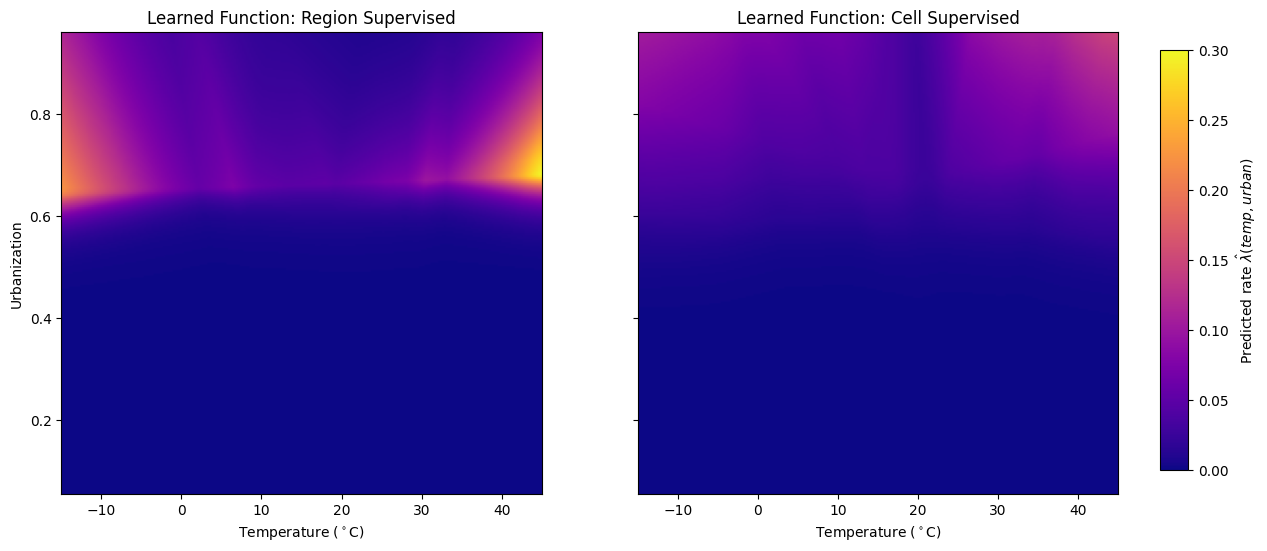

✅ Figures saved: model_comparison_side_by_side.png and individual files.


In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import os


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Helper function to generate prediction grid
def get_heatmap_data(model_path, t_range, u_range, mean_t, std_t):
    # Load model
    model = DisaggNN(hidden=64).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    # Create grid
    t_vals_raw = np.linspace(t_range[0], t_range[1], 250).astype(np.float32)
    u_vals = np.linspace(u_range[0], u_range[1], 250).astype(np.float32)
    Tg_raw, Ug = np.meshgrid(t_vals_raw, u_vals)

    # Normalize temperature for model input
    Tg_norm = (Tg_raw - mean_t) / (std_t + 1e-8)

    t_t = torch.tensor(Tg_norm, dtype=torch.float32, device=device).reshape(-1, 1)
    u_t = torch.tensor(Ug, dtype=torch.float32, device=device).reshape(-1, 1)
    x = torch.cat([t_t, u_t], dim=1)

    with torch.no_grad():
        # Apply model logic: softplus(net(x)) + epsilon
        lam = model.softplus(model.net(x)) + 1e-6
        lam_img = lam.reshape(len(u_vals), len(t_vals_raw)).cpu().numpy()

    return t_vals_raw, u_vals, lam_img

# --- CONFIGURATION ---
model_paths = {
    "Region Supervised": "/content/disagg_results/nn_region_supervised/best_model.pt",
    "Cell Supervised": "/content/disagg_results/nn_cell_supervised/best_model.pt"
}
temp_range = [-15, 45]
# Use your training urbanization range (typically 0 to 1)
u_min = float(context_sub.min().cpu()) if 'context_sub' in locals() else 0.0
u_max = float(context_sub.max().cpu()) if 'context_sub' in locals() else 1.0
urban_range = [u_min, u_max]

# --- DATA GENERATION ---
plot_data = {}
for label, path in model_paths.items():
    if os.path.exists(path):
        plot_data[label] = get_heatmap_data(path, temp_range, urban_range, mean_temp, std_temp)
    else:
        print(f"Warning: Model not found at {path}")

# --- PLOTTING SIDE BY SIDE ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for i, (label, (t_vals, u_vals, img)) in enumerate(plot_data.items()):
    im = axes[i].imshow(
        img,
        origin="lower",
        extent=[t_vals.min(), t_vals.max(), u_vals.min(), u_vals.max()],
        aspect="auto",
        cmap="plasma",
        vmin=0.0,
        vmax=0.30
    )
    axes[i].set_title(f"Learned Function: {label}")
    axes[i].set_xlabel("Temperature ($^\circ$C)")
    if i == 0:
        axes[i].set_ylabel("Urbanization")

# Add a common colorbar for the shared scale
fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.91, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax, label="Predicted rate $\hat{\lambda}(temp, urban)$")

plt.savefig("model_comparison_side_by_side.png", dpi=300, bbox_inches='tight')
plt.show()

# --- SAVING INDIVIDUAL FIGURES SEPARATELY ---
for label, (t_vals, u_vals, img) in plot_data.items():
    plt.figure(figsize=(7, 6))
    plt.imshow(
        img,
        origin="lower",
        extent=[t_vals.min(), t_vals.max(), u_vals.min(), u_vals.max()],
        aspect="auto",
        cmap="plasma",
        vmin=0.0,
        vmax=0.30
    )
    plt.colorbar(label="Predicted rate $\hat{\lambda}(temp, urban)$")
    plt.xlabel("Temperature ($^\circ$C)")
    plt.ylabel("Urbanization")
    plt.title(f"{label} Model: $f(temp, urban)$")
    plt.tight_layout()

    file_name = f"heatmap_{label.lower().replace(' ', '_')}.png"
    plt.savefig(file_name, dpi=300)
    plt.close()

print("✅ Figures saved: model_comparison_side_by_side.png and individual files.")

<>:61: SyntaxWarning: invalid escape sequence '\c'
<>:66: SyntaxWarning: invalid escape sequence '\h'
<>:78: SyntaxWarning: invalid escape sequence '\h'
<>:79: SyntaxWarning: invalid escape sequence '\c'
<>:61: SyntaxWarning: invalid escape sequence '\c'
<>:66: SyntaxWarning: invalid escape sequence '\h'
<>:78: SyntaxWarning: invalid escape sequence '\h'
<>:79: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipython-input-3907165644.py:61: SyntaxWarning: invalid escape sequence '\c'
  axes[i].set_xlabel("Temperature ($^\circ$C)")
/tmp/ipython-input-3907165644.py:66: SyntaxWarning: invalid escape sequence '\h'
  fig.colorbar(im, cax=cbar_ax, label="Predicted Outcome Rate $\hat{\lambda}$")
/tmp/ipython-input-3907165644.py:78: SyntaxWarning: invalid escape sequence '\h'
  plt.colorbar(label="Predicted Rate $\hat{\lambda}(temp, urban)$")
/tmp/ipython-input-3907165644.py:79: SyntaxWarning: invalid escape sequence '\c'
  plt.xlabel("Temperature ($^\circ$C)")


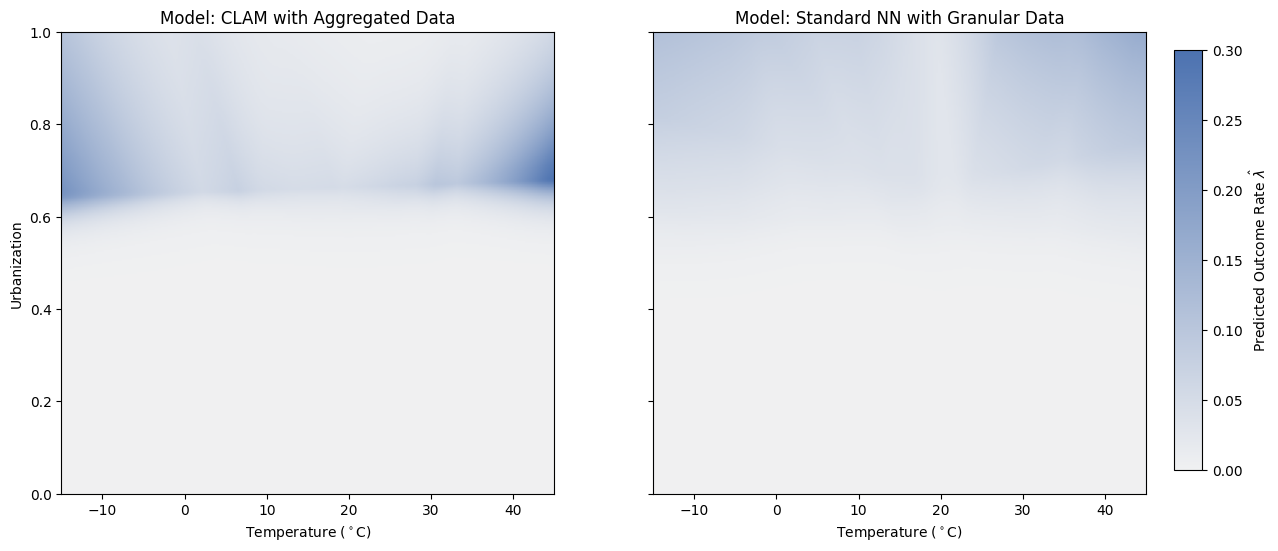

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- COLOR SETUP ---
colors = sns.color_palette("deep")
blue_cmap = sns.light_palette(colors[3], as_cmap=True)  # Blue for outcomes

# --- MODEL DEFINITION ---

def get_heatmap_data(model_path, t_range, u_range, mean_t, std_t, device):
    model = DisaggNN(hidden=64).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    t_vals_raw = np.linspace(t_range[0], t_range[1], 300).astype(np.float32)
    u_vals = np.linspace(u_range[0], u_range[1], 300).astype(np.float32)
    Tg_raw, Ug = np.meshgrid(t_vals_raw, u_vals)

    # Normalize for model input
    Tg_norm = (Tg_raw - mean_t) / (std_t + 1e-8)

    t_t = torch.tensor(Tg_norm, dtype=torch.float32, device=device).reshape(-1, 1)
    u_t = torch.tensor(Ug, dtype=torch.float32, device=device).reshape(-1, 1)
    x = torch.cat([t_t, u_t], dim=1)

    with torch.no_grad():
        lam = model.softplus(model.net(x)) + 1e-6
        lam_img = lam.reshape(len(u_vals), len(t_vals_raw)).cpu().numpy()

    return t_vals_raw, u_vals, lam_img

# --- EXECUTION ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_configs = {
    "Region Supervised": "/content/disagg_results/nn_region_supervised/best_model.pt",
    "Cell Supervised": "/content/disagg_results/nn_cell_supervised/best_model.pt"
}

t_range = [-15, 45]
u_range = [0, 1] # Or use u_min/u_max from your data
plot_results = {}

for label, path in model_configs.items():
    if os.path.exists(path):
        plot_results[label] = get_heatmap_data(path, t_range, u_range, mean_temp, std_temp, device)

# --- PLOTTING SIDE-BY-SIDE ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for i, (label, (t_vals, u_vals, img)) in enumerate(plot_results.items()):
    im = axes[i].imshow(
        img, origin="lower", aspect="auto",
        extent=[t_vals.min(), t_vals.max(), u_vals.min(), u_vals.max()],
        cmap=blue_cmap, vmin=0.0, vmax=0.30
    )
    axes[i].set_title(f"Model: {label}")
    axes[i].set_xlabel("Temperature ($^\circ$C)")
    if i == 0: axes[i].set_ylabel("Urbanization")

fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax, label="Predicted Outcome Rate $\hat{\lambda}$")
plt.savefig("comparison_heatmap_blue.png", dpi=300, bbox_inches='tight')
plt.show()

# --- SAVING INDIVIDUALS ---
for label, (t_vals, u_vals, img) in plot_results.items():
    plt.figure(figsize=(7, 6))
    plt.imshow(
        img, origin="lower", aspect="auto",
        extent=[t_vals.min(), t_vals.max(), u_vals.min(), u_vals.max()],
        cmap=blue_cmap, vmin=0.0, vmax=0.30
    )
    plt.colorbar(label="Predicted Rate $\hat{\lambda}(temp, urban)$")
    plt.xlabel("Temperature ($^\circ$C)")
    plt.ylabel("Urbanization")
    plt.title(f"Learned Function: {label}")
    plt.tight_layout()

    fname = f"final_heatmap_{label.lower().replace(' ', '_')}.png"
    plt.savefig(fname, dpi=300)
    plt.close()

In [ ]:
grid_height=grid_width=100

<>:83: SyntaxWarning: invalid escape sequence '\h'
<>:88: SyntaxWarning: invalid escape sequence '\h'
<>:83: SyntaxWarning: invalid escape sequence '\h'
<>:88: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipython-input-1640822448.py:83: SyntaxWarning: invalid escape sequence '\h'
  axes[1].set_title("CLAM Recovered Rate $\hat{\lambda}$", fontsize=14)
/tmp/ipython-input-1640822448.py:88: SyntaxWarning: invalid escape sequence '\h'
  axes[2].set_title("Granular Data based Rate $\hat{\lambda}$", fontsize=14)


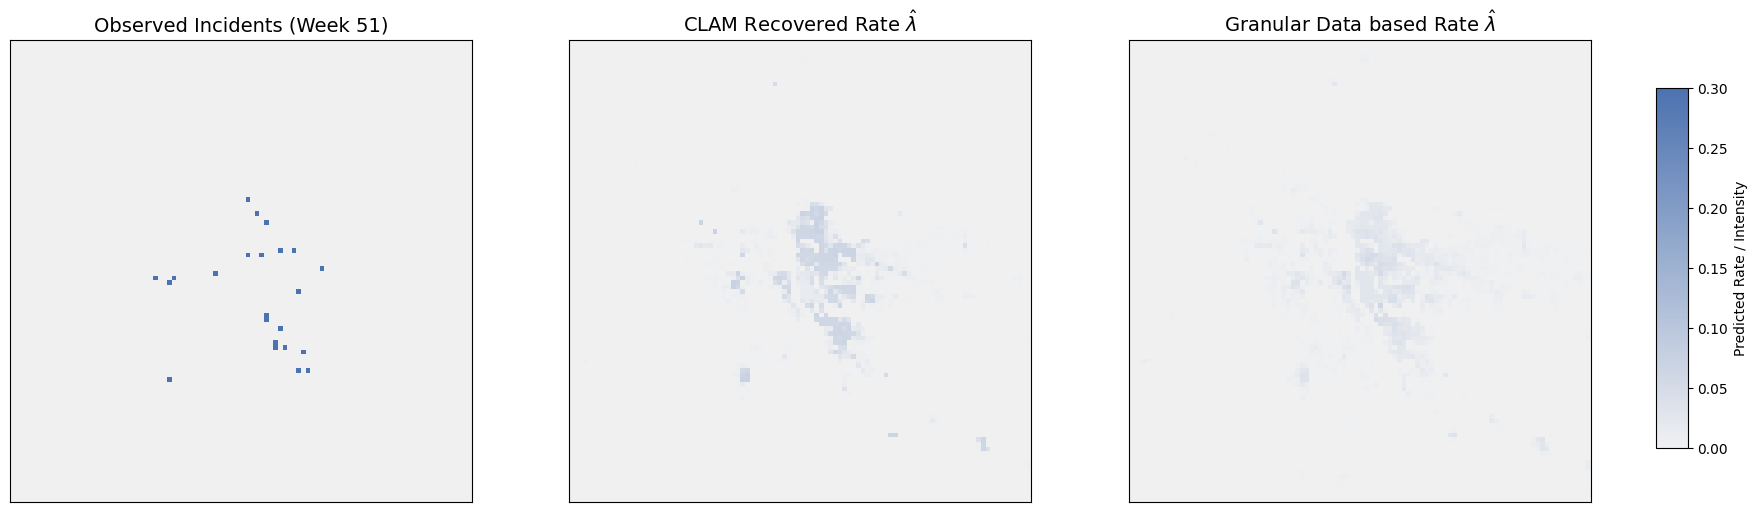

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- 1. RE-DEFINE ARCHITECTURE (Ensures consistency) ---
class DisaggNN(nn.Module):
    def __init__(self, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 1),
        )
        self.softplus = nn.Softplus(beta=1.0)

    def forward(self, temp_cell_grid_t, context_sub):
        # Expects: temp_cell_grid_t (100,100), context_sub (100,100)
        t = temp_cell_grid_t.reshape(-1, 1)  # (10000,1)
        u = context_sub.reshape(-1, 1)       # (10000,1)
        x = torch.cat([t, u], dim=1)         # (10000,2)

        rate = self.softplus(self.net(x)) + 1e-6
        rate_sub = rate.view(100, 100)       # Reshape back to spatial grid
        return rate_sub

# --- 2. CONFIGURATION ---
TARGET_WEEK_IDX = 50  # Index of the week you want to visualize
vmin, vmax = 0.0, 0.30
device = "cuda" if torch.cuda.is_available() else "cpu"

# Color palette setup
colors = sns.color_palette("deep")
blue_cmap = sns.light_palette(colors[0], as_cmap=True)

model_paths = {
    "Region Supervised": "/content/disagg_results/nn_region_supervised/best_model.pt",
    "Cell Supervised": "/content/disagg_results/nn_cell_supervised/best_model.pt"
}

# --- 3. INFERENCE & PLOTTING ---
def run_comparison(week_idx):
    results = {}

    # Load inputs (Ensure they are on the correct device)
    # temp_cell_T_t and context_sub are from your context script
    t_in = temp_cell_T_t[week_idx].to(device)
    u_in = context_sub.to(device)

    for label, path in model_paths.items():
        if not os.path.exists(path):
            print(f"Skipping {label}: Path not found.")
            continue

        # Load specific model weights
        m = DisaggNN(hidden=64).to(device)
        m.load_state_dict(torch.load(path, map_location=device))
        m.eval()

        with torch.no_grad():
            # Pass exactly 2 positional arguments as per DisaggNN.forward(self, t, u)
            pred_grid = m(t_in, u_in)
            results[label] = pred_grid.cpu().numpy()

    # Get Ground Truth
    observed = outcome_cell_T_t[week_idx].cpu().numpy()

    # --- Plotting ---
    fig, axes = plt.subplots(1, 3, figsize=(21, 6))
    plt.subplots_adjust(wspace=0.1)

    week_val = weeks[week_idx]

    # Observed
    im0 = axes[0].imshow(observed, origin="lower", cmap=blue_cmap, vmin=vmin, vmax=vmax)
    axes[0].set_title(f"Observed Incidents (Week {week_val})", fontsize=14)

    # Region Supervised
    if "Region Supervised" in results:
        im1 = axes[1].imshow(results["Region Supervised"], origin="lower", cmap=blue_cmap, vmin=vmin, vmax=vmax)
        axes[1].set_title("CLAM Recovered Rate $\hat{\lambda}$", fontsize=14)

    # Cell Supervised
    if "Cell Supervised" in results:
        im2 = axes[2].imshow(results["Cell Supervised"], origin="lower", cmap=blue_cmap, vmin=vmin, vmax=vmax)
        axes[2].set_title("Granular Data based Rate $\hat{\lambda}$", fontsize=14)

    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])

    # Add Colorbar
    cbar_ax = fig.add_axes([0.92, 0.2, 0.015, 0.6])
    fig.colorbar(im0, cax=cbar_ax, label="Predicted Rate / Intensity")

    plt.savefig(f"spatial_comparison_week_{week_val}.pdf", dpi=300, bbox_inches='tight')
    plt.show()

# Run the function
run_comparison(TARGET_WEEK_IDX)